# Preparación de datos para clasificación de potabilidad

Este notebook implementa, en el orden correcto:

1. división estratificada 80/20;
2. imputación aprendida únicamente con entrenamiento;
3. estandarización aprendida únicamente con entrenamiento;
4. balanceo con SMOTE aplicado exclusivamente al entrenamiento;
5. validaciones automáticas contra fuga de datos.

El conjunto de prueba permanece intacto y no se utiliza para ajustar ninguna transformación.

In [1]:
# Instalación de dependencia, si fuera necesaria
try:
    import imblearn
except ImportError:
    !pip -q install imbalanced-learn

In [2]:
# ============================================================
# 00. IMPORTACIONES Y CONFIGURACIÓN
# ============================================================
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "Potability"
EXPECTED_FEATURES = [
    "ph", "Hardness", "Solids", "Chloramines", "Sulfate",
    "Conductivity", "Organic_carbon", "Trihalomethanes", "Turbidity"
]

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", None)
print("Configuración lista.")

Configuración lista.


In [ ]:
# ============================================================
# 01. CARGA Y VALIDACIÓN ESTRUCTURAL
# ============================================================
import kagglehub
from pathlib import Path

KAGGLE_DATASET = "adityakadiwal/water-potability"
DATA_FILENAME = "water_potability.csv"

try:
    dataset_directory = Path(
        kagglehub.dataset_download(KAGGLE_DATASET)
    )

except Exception as exc:
    raise RuntimeError(
        "No fue posible descargar el dataset desde Kaggle. "
        "Verifique la conexión a Internet y la autenticación "
        f"de Kaggle. Detalle del error: {exc}"
    ) from exc

csv_matches = list(
    dataset_directory.rglob(DATA_FILENAME)
)

if len(csv_matches) == 0:
    available_csv_files = [
        path.name
        for path in dataset_directory.rglob("*.csv")
    ]

    raise FileNotFoundError(
        f"No se encontró el archivo '{DATA_FILENAME}' dentro "
        f"del dataset descargado. Archivos CSV disponibles: "
        f"{available_csv_files}"
    )

if len(csv_matches) > 1:
    raise RuntimeError(
        f"Se encontraron varias copias de '{DATA_FILENAME}': "
        f"{csv_matches}"
    )

DATA_PATH = csv_matches[0]

df = pd.read_csv(DATA_PATH)

df_original = df.copy(deep=True)

assert TARGET in df.columns, f"Falta la variable objetivo {TARGET}."
assert set(EXPECTED_FEATURES).issubset(df.columns), "Faltan variables predictoras esperadas."
assert set(df[TARGET].dropna().unique()).issubset({0, 1}), "La variable objetivo debe ser binaria: 0/1."
assert not np.isinf(df[EXPECTED_FEATURES].to_numpy(dtype=float)).any(), "Se detectaron valores infinitos."

print(f"Archivo: {DATA_PATH}")
print(f"Dimensiones: {df.shape}")
print()
print("Distribución original de clases:")
display(df[TARGET].value_counts().sort_index().rename("cantidad").to_frame())
print()
print("Valores faltantes:")
display(df[EXPECTED_FEATURES].isna().sum().rename("faltantes").to_frame())

Archivo: water_potability.csv
Dimensiones: (3276, 10)

Distribución original de clases:


,cantidad
Potability,
0,1998
1,1278



Valores faltantes:


,faltantes
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0


## 02. División estratificada 80/20

La separación se realiza **antes** de ajustar el imputador, el escalador o SMOTE. La estratificación conserva aproximadamente la proporción de las clases en entrenamiento y prueba.

In [4]:
# ============================================================
# 02. DIVISIÓN ESTRATIFICADA 80/20
# ============================================================
X = df[EXPECTED_FEATURES].copy()
y = df[TARGET].astype(int).copy()

# Se conservan los índices originales para comprobar independencia.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Entrenamiento: {X_train_raw.shape[0]} filas ({X_train_raw.shape[0]/len(df):.2%})")
print(f"Prueba:        {X_test_raw.shape[0]} filas ({X_test_raw.shape[0]/len(df):.2%})")

class_distribution = pd.DataFrame({
    "dataset_completo": y.value_counts(normalize=True).sort_index(),
    "entrenamiento": y_train.value_counts(normalize=True).sort_index(),
    "prueba": y_test.value_counts(normalize=True).sort_index()
}).rename_axis("clase")

display((class_distribution * 100).round(2).rename(columns=lambda c: f"{c} (%)"))

Entrenamiento: 2620 filas (79.98%)
Prueba:        656 filas (20.02%)


,dataset_completo (%),entrenamiento (%),prueba (%)
clase,,,
0,60.99,60.99,60.98
1,39.01,39.01,39.02


## 03. Imputación

Se usa imputación por mediana. El imputador se ajusta exclusivamente con `X_train_raw` y luego se reutiliza, sin reajustarlo, para transformar `X_test_raw`.

In [5]:
# ============================================================
# 03. IMPUTACIÓN SIN FUGA DE DATOS
# ============================================================
imputer = SimpleImputer(strategy="median")

X_train_imputed_array = imputer.fit_transform(X_train_raw)
X_test_imputed_array = imputer.transform(X_test_raw)

X_train_imputed = pd.DataFrame(
    X_train_imputed_array,
    columns=EXPECTED_FEATURES,
    index=X_train_raw.index
)
X_test_imputed = pd.DataFrame(
    X_test_imputed_array,
    columns=EXPECTED_FEATURES,
    index=X_test_raw.index
)

imputation_summary = pd.DataFrame({
    "faltantes_train_antes": X_train_raw.isna().sum(),
    "faltantes_test_antes": X_test_raw.isna().sum(),
    "mediana_aprendida_solo_train": imputer.statistics_,
    "faltantes_train_despues": X_train_imputed.isna().sum(),
    "faltantes_test_despues": X_test_imputed.isna().sum()
})

display(imputation_summary)

,faltantes_train_antes,faltantes_test_antes,mediana_aprendida_solo_train,faltantes_train_despues,faltantes_test_despues
ph,387,104,7.035037,0,0
Hardness,0,0,196.928061,0,0
Solids,0,0,20866.335842,0,0
Chloramines,0,0,7.118162,0,0
Sulfate,625,156,333.073546,0,0
Conductivity,0,0,424.941336,0,0
Organic_carbon,0,0,14.214780,0,0
Trihalomethanes,134,28,66.565709,0,0
Turbidity,0,0,3.969602,0,0


## 04. Estandarización

El escalador aprende la media y la desviación estándar únicamente del entrenamiento imputado. Esas mismas estadísticas se aplican al conjunto de prueba.

In [6]:
# ============================================================
# 04. ESTANDARIZACIÓN SIN FUGA DE DATOS
# ============================================================
scaler = StandardScaler()

X_train_scaled_array = scaler.fit_transform(X_train_imputed)
X_test_scaled_array = scaler.transform(X_test_imputed)

X_train_scaled = pd.DataFrame(
    X_train_scaled_array,
    columns=EXPECTED_FEATURES,
    index=X_train_raw.index
)
X_test_scaled = pd.DataFrame(
    X_test_scaled_array,
    columns=EXPECTED_FEATURES,
    index=X_test_raw.index
)

scaling_summary = pd.DataFrame({
    "media_aprendida_train": scaler.mean_,
    "desv_aprendida_train": scaler.scale_,
    "media_train_transformado": X_train_scaled.mean(),
    "desv_train_transformado": X_train_scaled.std(ddof=0),
    "media_test_transformado": X_test_scaled.mean(),
    "desv_test_transformado": X_test_scaled.std(ddof=0)
}, index=EXPECTED_FEATURES)

display(scaling_summary.round(6))

,media_aprendida_train,desv_aprendida_train,media_train_transformado,desv_train_transformado,media_test_transformado,desv_test_transformado
ph,7.079959,1.469526,0.0,1.0,-0.020465,1.000840
Hardness,196.520827,32.631484,-0.0,1.0,-0.023160,1.036487
Solids,21888.067749,8758.437411,0.0,1.0,0.071857,1.002948
Chloramines,7.116362,1.598915,0.0,1.0,0.018473,0.948599
Sulfate,333.769722,36.229228,0.0,1.0,-0.022242,0.987207
Conductivity,427.915853,80.928356,0.0,1.0,-0.105566,0.988283
Organic_carbon,14.272735,3.295927,-0.0,1.0,0.018539,1.017514
Trihalomethanes,66.164349,15.792200,-0.0,1.0,0.075996,0.989839
Turbidity,3.973783,0.780193,-0.0,1.0,-0.044783,0.999646


## 05. Balanceo con SMOTE

SMOTE se aplica únicamente al entrenamiento ya imputado y estandarizado. El conjunto de prueba no se remuestrea ni se modifica.

In [7]:
# ============================================================
# 05. BALANCEO CON SMOTE SOLO EN ENTRENAMIENTO
# ============================================================
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote_array, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

X_train_smote = pd.DataFrame(X_train_smote_array, columns=EXPECTED_FEATURES)
y_train_smote = pd.Series(y_train_smote, name=TARGET)

balance_summary = pd.DataFrame({
    "train_antes_SMOTE": y_train.value_counts().sort_index(),
    "train_despues_SMOTE": y_train_smote.value_counts().sort_index(),
    "test_sin_balancear": y_test.value_counts().sort_index()
}).fillna(0).astype(int).rename_axis("clase")

display(balance_summary)
print(f"Tamaño de entrenamiento antes de SMOTE: {len(y_train)}")
print(f"Tamaño de entrenamiento después de SMOTE: {len(y_train_smote)}")
print(f"Tamaño de prueba, sin cambios: {len(y_test)}")

,train_antes_SMOTE,train_despues_SMOTE,test_sin_balancear
clase,,,
0,1598,1598,400
1,1022,1598,256


Tamaño de entrenamiento antes de SMOTE: 2620
Tamaño de entrenamiento después de SMOTE: 3196
Tamaño de prueba, sin cambios: 656


## 06. Validaciones contra fuga de datos

Las siguientes pruebas fallan mediante `AssertionError` si se detecta una inconsistencia importante.

In [8]:
# ============================================================
# 06. VALIDACIONES AUTOMÁTICAS CONTRA FUGA DE DATOS
# ============================================================

def dataframe_hash(frame: pd.DataFrame) -> str:
    # Hash reproducible para verificar que un DataFrame no fue modificado.
    hashed = pd.util.hash_pandas_object(frame, index=True).values.tobytes()
    return hashlib.sha256(hashed).hexdigest()

# 1) Independencia de índices entre entrenamiento y prueba.
assert set(X_train_raw.index).isdisjoint(set(X_test_raw.index)),     "Fuga detectada: entrenamiento y prueba comparten índices."

# 2) La unión de ambos subconjuntos contiene todas las filas originales una sola vez.
assert len(X_train_raw) + len(X_test_raw) == len(X),     "La división perdió o duplicó observaciones."
assert set(X_train_raw.index).union(set(X_test_raw.index)) == set(X.index),     "La división no cubre exactamente los índices originales."

# 3) Estratificación razonable: las proporciones no deben diferir mucho de la original.
original_rate = y.mean()
assert abs(y_train.mean() - original_rate) < 0.01,     "La proporción de clases en entrenamiento difiere demasiado de la original."
assert abs(y_test.mean() - original_rate) < 0.01,     "La proporción de clases en prueba difiere demasiado de la original."

# 4) No quedan faltantes después de la imputación.
assert X_train_imputed.isna().sum().sum() == 0, "Quedan NaN en entrenamiento imputado."
assert X_test_imputed.isna().sum().sum() == 0, "Quedan NaN en prueba imputada."

# 5) Las estadísticas del imputador coinciden con medianas calculadas SOLO en entrenamiento.
train_medians = X_train_raw.median(numeric_only=True).to_numpy()
assert np.allclose(imputer.statistics_, train_medians, equal_nan=True),     "El imputador no coincide con las medianas del entrenamiento."

# 6) El escalador aprendió estadísticas SOLO del entrenamiento imputado.
assert np.allclose(scaler.mean_, X_train_imputed.mean().to_numpy()),     "La media del escalador no coincide con el entrenamiento imputado."
assert np.allclose(scaler.var_, X_train_imputed.var(ddof=0).to_numpy()),     "La varianza del escalador no coincide con el entrenamiento imputado."

# 7) El entrenamiento escalado tiene media ~0 y desviación ~1.
assert np.allclose(X_train_scaled.mean().to_numpy(), 0, atol=1e-10),     "El entrenamiento escalado no tiene media cercana a cero."
assert np.allclose(X_train_scaled.std(ddof=0).to_numpy(), 1, atol=1e-10),     "El entrenamiento escalado no tiene desviación cercana a uno."

# 8) SMOTE produjo balance exacto en entrenamiento.
smote_counts = y_train_smote.value_counts()
assert smote_counts.nunique() == 1, "SMOTE no dejó las clases balanceadas."

# 9) El test conserva exactamente su tamaño, índices y etiquetas originales.
assert len(X_test_scaled) == len(X_test_raw) == len(y_test),     "El conjunto de prueba cambió de tamaño."
assert X_test_scaled.index.equals(X_test_raw.index),     "Los índices de prueba cambiaron durante el preprocesamiento."
assert y_test.index.equals(X_test_raw.index),     "Las etiquetas de prueba perdieron alineación con sus observaciones."

# 10) Los datos originales no fueron modificados.
assert df_original.equals(df), "El DataFrame original fue modificado accidentalmente."

print("✓ División estratificada validada.")
print("✓ Entrenamiento y prueba no comparten observaciones.")
print("✓ Imputador ajustado únicamente con entrenamiento.")
print("✓ Escalador ajustado únicamente con entrenamiento.")
print("✓ SMOTE aplicado únicamente al entrenamiento.")
print("✓ Conjunto de prueba intacto y sin balancear.")
print("✓ No se detectaron fugas de datos en este flujo.")

✓ División estratificada validada.
✓ Entrenamiento y prueba no comparten observaciones.
✓ Imputador ajustado únicamente con entrenamiento.
✓ Escalador ajustado únicamente con entrenamiento.
✓ SMOTE aplicado únicamente al entrenamiento.
✓ Conjunto de prueba intacto y sin balancear.
✓ No se detectaron fugas de datos en este flujo.


## 07. Objetos disponibles para las siguientes fases

- `X_train_smote`, `y_train_smote`: entrenamiento transformado y balanceado para un ajuste simple.
- `X_test_scaled`, `y_test`: prueba imputada y estandarizada, pero nunca balanceada.
- `X_train_raw`, `y_train`: entrenamiento original, necesario para validación cruzada sin fuga.

Para `GridSearchCV`, no se debe usar directamente `X_train_smote`, porque SMOTE debe ejecutarse dentro de cada fold. El pipeline siguiente deja preparado el orden correcto para incorporar un clasificador.

In [9]:
# ============================================================
# 07. PIPELINE SEGURO PARA VALIDACIÓN CRUZADA FUTURA
# ============================================================
# Reemplace "passthrough" por el clasificador, por ejemplo SVC(kernel='rbf').
preprocessing_pipeline_for_cv = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", "passthrough")
])

print(preprocessing_pipeline_for_cv)
print()
print("Este pipeline debe ajustarse sobre X_train_raw y y_train dentro de GridSearchCV.")

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('classifier', 'passthrough')])

Este pipeline debe ajustarse sobre X_train_raw y y_train dentro de GridSearchCV.


In [10]:
# ============================================================
# 08. RESUMEN FINAL
# ============================================================
final_summary = pd.DataFrame({
    "etapa": [
        "Dataset original",
        "Entrenamiento antes de SMOTE",
        "Entrenamiento después de SMOTE",
        "Prueba reservada"
    ],
    "filas": [len(df), len(y_train), len(y_train_smote), len(y_test)],
    "faltantes_predictoras": [
        int(df[EXPECTED_FEATURES].isna().sum().sum()),
        int(X_train_raw.isna().sum().sum()),
        int(X_train_smote.isna().sum().sum()),
        int(X_test_scaled.isna().sum().sum())
    ],
    "balanceado": [False, False, True, False]
})

display(final_summary)
print("Preparación completada correctamente.")

,etapa,filas,faltantes_predictoras,balanceado
0,Dataset original,3276,1434,False
1,Entrenamiento antes de SMOTE,2620,1146,False
2,Entrenamiento después de SMOTE,3196,0,True
3,Prueba reservada,656,0,False


Preparación completada correctamente.


# Fase 2. Modelo clásico SVM-RBF

Esta fase incorpora:

11. entrenamiento inicial de una SVM con kernel RBF;
12. optimización de `C` y `gamma` mediante `GridSearchCV` con cinco folds estratificados;
13. evaluación final sobre el conjunto de prueba reservado.

La imputación, la estandarización y SMOTE permanecen dentro del pipeline durante la validación cruzada. De esta manera, cada fold aprende sus transformaciones exclusivamente con su propia partición de entrenamiento.

## 11. Entrenamiento inicial SVM-RBF

Primero se evalúa una configuración base de la SVM-RBF mediante validación cruzada sobre el conjunto de entrenamiento original. El conjunto de prueba todavía no se utiliza.

In [11]:
# ============================================================
# 11. ENTRENAMIENTO INICIAL SVM-RBF
# ============================================================
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

CV_FOLDS = 5

cv_strategy = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

svm_baseline_pipeline = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=RANDOM_STATE
    ))
])

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

baseline_cv_results = cross_validate(
    estimator=svm_baseline_pipeline,
    X=X_train_raw,
    y=y_train,
    cv=cv_strategy,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

baseline_summary = pd.DataFrame({
    metric: [
        baseline_cv_results[f"test_{metric}"].mean(),
        baseline_cv_results[f"test_{metric}"].std(ddof=1)
    ]
    for metric in scoring
}, index=["media_cv", "desviacion_cv"]).T

print("Resultados de validación cruzada de la SVM-RBF inicial:")
display(baseline_summary.round(4))

Resultados de validación cruzada de la SVM-RBF inicial:


,media_cv,desviacion_cv
accuracy,0.6412,0.0176
balanced_accuracy,0.6374,0.0199
precision,0.5352,0.0201
recall,0.6203,0.0642
f1,0.5733,0.0285
roc_auc,0.6944,0.0258


## 12. GridSearchCV con cinco folds

Se evalúa la cuadrícula solicitada por el Challenge:

- `C`: 0.1, 1 y 10;
- `gamma`: `scale`, `auto` y 0.01;
- kernel fijo: RBF.

La selección se realiza con F1 como métrica principal, debido al desbalance original de las clases. También se conservan accuracy, balanced accuracy, precision, recall y ROC AUC.

In [12]:
# ============================================================
# 12. GRIDSEARCHCV CON CINCO FOLDS
# ============================================================
from sklearn.model_selection import GridSearchCV

svm_grid_pipeline = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", SVC(
        kernel="rbf",
        probability=True,
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "classifier__C": [0.1, 1, 10],
    "classifier__gamma": ["scale", "auto", 0.01]
}

grid_search = GridSearchCV(
    estimator=svm_grid_pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit="f1",
    cv=cv_strategy,
    n_jobs=-1,
    return_train_score=True,
    verbose=0
)

grid_search.fit(X_train_raw, y_train)

print("Mejores hiperparámetros:")
print(grid_search.best_params_)
print(f"Mejor F1 medio de validación cruzada: {grid_search.best_score_:.4f}")

cv_results = pd.DataFrame(grid_search.cv_results_)

grid_results_table = cv_results[[
    "param_classifier__C",
    "param_classifier__gamma",
    "mean_test_accuracy",
    "mean_test_balanced_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "std_test_f1",
    "mean_test_roc_auc",
    "mean_fit_time"
]].copy()

grid_results_table = grid_results_table.rename(columns={
    "param_classifier__C": "C",
    "param_classifier__gamma": "gamma",
    "mean_test_accuracy": "accuracy_cv",
    "mean_test_balanced_accuracy": "balanced_accuracy_cv",
    "mean_test_precision": "precision_cv",
    "mean_test_recall": "recall_cv",
    "mean_test_f1": "f1_cv",
    "std_test_f1": "f1_std",
    "mean_test_roc_auc": "roc_auc_cv",
    "mean_fit_time": "tiempo_ajuste_s"
}).sort_values("f1_cv", ascending=False)

display(grid_results_table.round(4).reset_index(drop=True))

Mejores hiperparámetros:
{'classifier__C': 1, 'classifier__gamma': 'auto'}
Mejor F1 medio de validación cruzada: 0.5740


,C,gamma,accuracy_cv,balanced_accuracy_cv,precision_cv,recall_cv,f1_cv,f1_std,roc_auc_cv,tiempo_ajuste_s
0,1.0,auto,0.6412,0.6377,0.5350,0.6222,0.5740,0.0247,0.6939,2.5783
1,1.0,scale,0.6412,0.6374,0.5352,0.6203,0.5733,0.0255,0.6944,2.7446
2,10.0,auto,0.6378,0.6298,0.5330,0.5939,0.5605,0.0195,0.6913,3.1740
3,10.0,scale,0.6370,0.6290,0.5319,0.5929,0.5596,0.0200,0.6903,3.6797
4,10.0,0.01,0.6176,0.6072,0.5091,0.5606,0.5303,0.0465,0.6588,2.5948
5,0.1,scale,0.6107,0.6013,0.5018,0.5587,0.5272,0.0341,0.6459,6.9345
6,0.1,auto,0.6107,0.6011,0.5017,0.5577,0.5267,0.0332,0.6450,3.5864
7,1.0,0.01,0.6050,0.5597,0.5092,0.3541,0.4064,0.0533,0.5879,2.8811
8,0.1,0.01,0.5908,0.5206,0.4549,0.2015,0.2684,0.0668,0.5027,2.9750


## 13. Evaluación clásica

El mejor pipeline se evalúa una sola vez sobre el conjunto de prueba reservado. El test conserva la distribución original y nunca recibe SMOTE.

Se reportan:

- accuracy;
- balanced accuracy;
- precision;
- recall;
- F1;
- ROC AUC;
- PR AUC;
- matriz de confusión;
- reporte de clasificación;
- curvas ROC y precision-recall.

Métricas finales en el conjunto de prueba reservado:


,métrica,valor
0,Accuracy,0.6143
1,Balanced accuracy,0.5987
2,Precision,0.5056
3,Recall,0.5273
4,F1,0.5163
5,ROC AUC,0.6479
6,PR AUC,0.5643


Matriz de confusión:


,Predicho: no potable,Predicho: potable
Real: no potable,268,132
Real: potable,121,135


Reporte de clasificación:
              precision    recall  f1-score   support

  No potable     0.6889    0.6700    0.6793       400
     Potable     0.5056    0.5273    0.5163       256

    accuracy                         0.6143       656
   macro avg     0.5973    0.5987    0.5978       656
weighted avg     0.6174    0.6143    0.6157       656



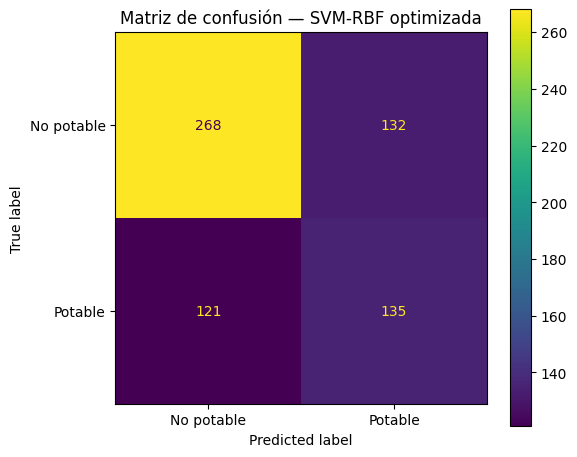

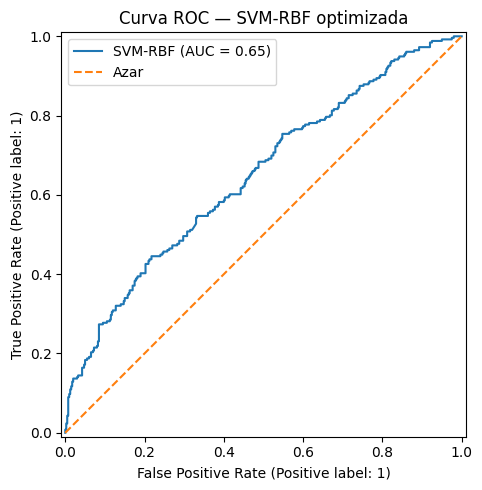

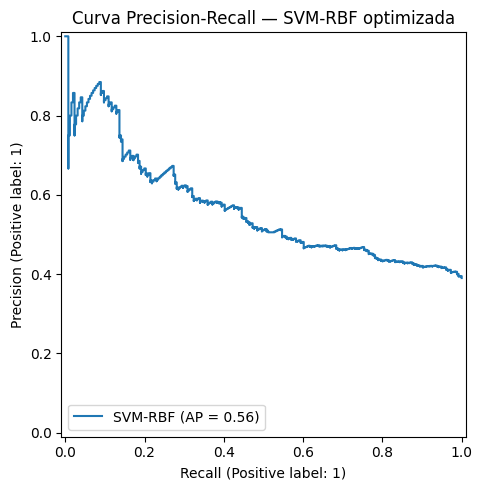

In [13]:
# ============================================================
# 13. EVALUACIÓN FINAL SOBRE EL CONJUNTO DE PRUEBA
# ============================================================
best_svm_model = grid_search.best_estimator_

# GridSearchCV ya reajustó el mejor pipeline usando todo el entrenamiento.
y_test_pred = best_svm_model.predict(X_test_raw)
y_test_proba = best_svm_model.predict_proba(X_test_raw)[:, 1]

classical_metrics = pd.DataFrame({
    "métrica": [
        "Accuracy",
        "Balanced accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC",
        "PR AUC"
    ],
    "valor": [
        accuracy_score(y_test, y_test_pred),
        balanced_accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0),
        roc_auc_score(y_test, y_test_proba),
        average_precision_score(y_test, y_test_proba)
    ]
})

print("Métricas finales en el conjunto de prueba reservado:")
display(classical_metrics.round(4))

cm = confusion_matrix(y_test, y_test_pred)
cm_table = pd.DataFrame(
    cm,
    index=["Real: no potable", "Real: potable"],
    columns=["Predicho: no potable", "Predicho: potable"]
)

print("Matriz de confusión:")
display(cm_table)

print("Reporte de clasificación:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["No potable", "Potable"],
    digits=4,
    zero_division=0
))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No potable", "Potable"]
).plot(ax=ax, values_format="d")
ax.set_title("Matriz de confusión — SVM-RBF optimizada")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba,
    name="SVM-RBF",
    ax=ax
)
ax.plot([0, 1], [0, 1], linestyle="--", label="Azar")
ax.set_title("Curva ROC — SVM-RBF optimizada")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_proba,
    name="SVM-RBF",
    ax=ax
)
ax.set_title("Curva Precision-Recall — SVM-RBF optimizada")
plt.tight_layout()
plt.show()

## 14. Validaciones adicionales de integridad

Estas comprobaciones verifican que:

- el mejor estimador contiene imputación, escalado, SMOTE y SVM;
- SMOTE no se aplicó al conjunto de prueba;
- los índices de entrenamiento y prueba continúan separados;
- el tamaño del test no cambió;
- el modelo final utiliza kernel RBF;
- la búsqueda evaluó las nueve combinaciones esperadas.

In [14]:
# ============================================================
# 14. VALIDACIONES ADICIONALES DE INTEGRIDAD
# ============================================================
expected_steps = ["imputer", "scaler", "smote", "classifier"]
assert list(best_svm_model.named_steps.keys()) == expected_steps, (
    "El pipeline final no contiene las etapas esperadas."
)

assert set(X_train_raw.index).isdisjoint(set(X_test_raw.index)), (
    "Fuga detectada: entrenamiento y prueba comparten índices."
)

assert len(y_test_pred) == len(y_test) == len(X_test_raw), (
    "El tamaño del conjunto de prueba fue alterado."
)

assert best_svm_model.named_steps["classifier"].kernel == "rbf", (
    "El clasificador final no utiliza kernel RBF."
)

assert len(cv_results) == 9, (
    "GridSearchCV no evaluó las nueve combinaciones de C y gamma."
)

assert y_test.value_counts().to_dict() == df.loc[X_test_raw.index, TARGET].value_counts().to_dict(), (
    "La distribución del conjunto de prueba fue modificada."
)

# Verificación de que el muestreo solo ocurre durante fit:
test_rows_before = len(X_test_raw)
_ = best_svm_model.predict(X_test_raw)
test_rows_after = len(X_test_raw)
assert test_rows_before == test_rows_after, (
    "El conjunto de prueba cambió durante la predicción."
)

print("✓ Pipeline final completo.")
print("✓ GridSearchCV evaluó 9 combinaciones con 5 folds.")
print("✓ Entrenamiento y prueba permanecen independientes.")
print("✓ El conjunto de prueba no fue balanceado ni modificado.")
print("✓ Evaluación clásica completada sin fuga de datos.")

✓ Pipeline final completo.
✓ GridSearchCV evaluó 9 combinaciones con 5 folds.
✓ Entrenamiento y prueba permanecen independientes.
✓ El conjunto de prueba no fue balanceado ni modificado.
✓ Evaluación clásica completada sin fuga de datos.


# 15. Evaluación reproducible con tres semillas

Se repite el proceso completo con las semillas **42, 123 y 2026**. En cada ejecución se realiza una nueva división estratificada 80/20, imputación, estandarización, SMOTE, búsqueda de hiperparámetros con cinco folds y evaluación sobre un conjunto de prueba reservado.

Los resultados se consolidan como **media ± desviación estándar** y se exportan automáticamente junto con las figuras y tablas necesarias para reproducir el informe.

In [15]:
# ============================================================
# 15. CONFIGURACIÓN REPRODUCIBLE Y DIRECTORIOS DE SALIDA
# ============================================================
from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, RocCurveDisplay,
    PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

SEEDS = [42, 123, 2026]
TEST_SIZE_MULTI = 0.20
CV_FOLDS_MULTI = 5

OUTPUT_DIR = Path("outputs_svm_rbf")
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
REPORTS_DIR = OUTPUT_DIR / "reports"
MODELS_DIR = OUTPUT_DIR / "models"

for directory in [OUTPUT_DIR, TABLES_DIR, FIGURES_DIR, REPORTS_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Resultados reproducibles en: {OUTPUT_DIR.resolve()}")
print(f"Semillas: {SEEDS}")

Resultados reproducibles en: /content/outputs_svm_rbf
Semillas: [42, 123, 2026]


In [16]:
# ============================================================
# 16. FUNCIÓN PARA EJECUTAR UNA SEMILLA COMPLETA
# ============================================================
def run_seed_experiment(seed: int):
    start = time.perf_counter()

    # División estratificada independiente para esta semilla
    X_train_seed, X_test_seed, y_train_seed, y_test_seed = train_test_split(
        X, y,
        test_size=TEST_SIZE_MULTI,
        stratify=y,
        random_state=seed
    )

    # Comprobaciones contra fuga de datos
    assert set(X_train_seed.index).isdisjoint(set(X_test_seed.index))
    assert len(X_train_seed) + len(X_test_seed) == len(X)

    pipeline = ImbPipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=seed)),
        ("classifier", SVC(
            kernel="rbf",
            probability=False,
            random_state=seed
        ))
    ])

    cv = StratifiedKFold(
        n_splits=CV_FOLDS_MULTI,
        shuffle=True,
        random_state=seed
    )

    scoring_multi = {
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }

    param_grid_multi = {
        "classifier__C": [0.1, 1, 10],
        "classifier__gamma": ["scale", "auto", 0.01]
    }

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid_multi,
        scoring=scoring_multi,
        refit="f1",
        cv=cv,
        n_jobs=-1,
        return_train_score=False,
        verbose=0
    )
    grid.fit(X_train_seed, y_train_seed)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_seed)
    y_score = best_model.decision_function(X_test_seed)

    metrics = {
        "seed": seed,
        "accuracy": accuracy_score(y_test_seed, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test_seed, y_pred),
        "precision": precision_score(y_test_seed, y_pred, zero_division=0),
        "recall": recall_score(y_test_seed, y_pred, zero_division=0),
        "f1": f1_score(y_test_seed, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test_seed, y_score),
        "pr_auc": average_precision_score(y_test_seed, y_score),
        "best_cv_f1": grid.best_score_,
        "best_C": grid.best_params_["classifier__C"],
        "best_gamma": grid.best_params_["classifier__gamma"],
        "runtime_seconds": time.perf_counter() - start
    }

    grid_df = pd.DataFrame(grid.cv_results_)[[
        "param_classifier__C", "param_classifier__gamma",
        "mean_test_accuracy", "mean_test_balanced_accuracy",
        "mean_test_precision", "mean_test_recall",
        "mean_test_f1", "std_test_f1",
        "mean_test_roc_auc", "mean_fit_time"
    ]].copy()
    grid_df.insert(0, "seed", seed)
    grid_df = grid_df.rename(columns={
        "param_classifier__C": "C",
        "param_classifier__gamma": "gamma",
        "mean_test_accuracy": "accuracy_cv",
        "mean_test_balanced_accuracy": "balanced_accuracy_cv",
        "mean_test_precision": "precision_cv",
        "mean_test_recall": "recall_cv",
        "mean_test_f1": "f1_cv",
        "std_test_f1": "f1_std",
        "mean_test_roc_auc": "roc_auc_cv",
        "mean_fit_time": "fit_time_s"
    }).sort_values("f1_cv", ascending=False)

    cm = confusion_matrix(y_test_seed, y_pred)
    report = classification_report(
        y_test_seed, y_pred,
        target_names=["No potable", "Potable"],
        digits=4,
        zero_division=0
    )

    return {
        "metrics": metrics,
        "grid": grid_df,
        "cm": cm,
        "report": report,
        "y_test": y_test_seed,
        "y_pred": y_pred,
        "y_score": y_score,
        "best_params": grid.best_params_
    }

In [17]:
# ============================================================
# 17. EJECUCIÓN DE LAS TRES SEMILLAS Y EXPORTACIÓN POR SEMILLA
# ============================================================
results_by_seed = {}
metrics_rows = []
grid_rows = []
cm_rows = []
best_params_by_seed = {}

for seed in SEEDS:
    print(f"Ejecutando semilla {seed}...")
    result = run_seed_experiment(seed)
    results_by_seed[seed] = result
    metrics_rows.append(result["metrics"])
    grid_rows.append(result["grid"])
    best_params_by_seed[str(seed)] = result["best_params"]

    cm = result["cm"]
    cm_rows.append(pd.DataFrame({
        "seed": [seed, seed],
        "clase_real": ["No potable", "Potable"],
        "pred_no_potable": [cm[0, 0], cm[1, 0]],
        "pred_potable": [cm[0, 1], cm[1, 1]]
    }))

    pd.DataFrame([result["metrics"]]).to_csv(
        TABLES_DIR / f"metricas_test_seed_{seed}.csv", index=False
    )
    result["grid"].to_csv(
        TABLES_DIR / f"gridsearch_seed_{seed}.csv", index=False
    )
    (REPORTS_DIR / f"classification_report_seed_{seed}.txt").write_text(
        result["report"], encoding="utf-8"
    )

    # Matriz de confusión
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(
        confusion_matrix=result["cm"],
        display_labels=["No potable", "Potable"]
    ).plot(ax=ax, values_format="d")
    ax.set_title(f"Matriz de confusión — semilla {seed}")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"matriz_confusion_seed_{seed}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

    # ROC
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(
        result["y_test"], result["y_score"],
        name=f"SVM-RBF seed {seed}", ax=ax
    )
    ax.plot([0, 1], [0, 1], linestyle="--", label="Azar")
    ax.set_title(f"Curva ROC — semilla {seed}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"curva_roc_seed_{seed}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

    # Precision-Recall
    fig, ax = plt.subplots(figsize=(6, 5))
    PrecisionRecallDisplay.from_predictions(
        result["y_test"], result["y_score"],
        name=f"SVM-RBF seed {seed}", ax=ax
    )
    ax.set_title(f"Curva Precision-Recall — semilla {seed}")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"curva_precision_recall_seed_{seed}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(
        f"  F1={result['metrics']['f1']:.4f} | "
        f"Balanced Accuracy={result['metrics']['balanced_accuracy']:.4f} | "
        f"ROC AUC={result['metrics']['roc_auc']:.4f}"
    )

print("✓ Tres ejecuciones completadas.")

Ejecutando semilla 42...
  F1=0.5163 | Balanced Accuracy=0.5987 | ROC AUC=0.6480
Ejecutando semilla 123...
  F1=0.5403 | Balanced Accuracy=0.6049 | ROC AUC=0.6655
Ejecutando semilla 2026...
  F1=0.5554 | Balanced Accuracy=0.6148 | ROC AUC=0.6685
✓ Tres ejecuciones completadas.


# 18. Tabla principal del informe

La tabla principal incluye `Balanced Accuracy` y resume la estabilidad del modelo mediante la media y la desviación estándar de las tres ejecuciones.

In [18]:
# ============================================================
# 18. CONSOLIDACIÓN: MEDIA ± DESVIACIÓN ESTÁNDAR
# ============================================================
metrics_by_seed_df = pd.DataFrame(metrics_rows)
all_grid_results_df = pd.concat(grid_rows, ignore_index=True)
all_confusion_matrices_df = pd.concat(cm_rows, ignore_index=True)

metric_columns = [
    "accuracy", "balanced_accuracy", "precision",
    "recall", "f1", "roc_auc", "pr_auc"
]
metric_names = {
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "roc_auc": "ROC AUC",
    "pr_auc": "PR AUC"
}

summary_metrics_df = pd.DataFrame([
    {
        "Métrica": metric_names[m],
        "Media": metrics_by_seed_df[m].mean(),
        "Desviación estándar": metrics_by_seed_df[m].std(ddof=1),
        "Media ± DE": f"{metrics_by_seed_df[m].mean():.4f} ± {metrics_by_seed_df[m].std(ddof=1):.4f}"
    }
    for m in metric_columns
])

print("Resultados por semilla:")
display(metrics_by_seed_df[[
    "seed", "accuracy", "balanced_accuracy", "precision",
    "recall", "f1", "roc_auc", "pr_auc",
    "best_C", "best_gamma", "runtime_seconds"
]].round(4))

print("Tabla principal del informe:")
display(summary_metrics_df)

# Exportaciones consolidadas
metrics_by_seed_df.to_csv(TABLES_DIR / "metricas_por_semilla.csv", index=False)
summary_metrics_df.to_csv(TABLES_DIR / "tabla_principal_media_desviacion.csv", index=False)
all_grid_results_df.to_csv(TABLES_DIR / "gridsearch_todas_las_semillas.csv", index=False)
all_confusion_matrices_df.to_csv(TABLES_DIR / "matrices_confusion_todas_las_semillas.csv", index=False)

with open(REPORTS_DIR / "mejores_hiperparametros_por_semilla.json", "w", encoding="utf-8") as f:
    json.dump(best_params_by_seed, f, ensure_ascii=False, indent=2)

# También se guarda en Excel para facilitar el informe
with pd.ExcelWriter(TABLES_DIR / "resultados_svm_rbf.xlsx") as writer:
    metrics_by_seed_df.to_excel(writer, sheet_name="Metricas por semilla", index=False)
    summary_metrics_df.to_excel(writer, sheet_name="Resumen media DE", index=False)
    all_grid_results_df.to_excel(writer, sheet_name="GridSearch", index=False)
    all_confusion_matrices_df.to_excel(writer, sheet_name="Matrices confusion", index=False)

print("✓ Tablas CSV y Excel guardadas.")

Resultados por semilla:


,seed,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,best_C,best_gamma,runtime_seconds
0,42,0.6143,0.5987,0.5056,0.5273,0.5163,0.6480,0.5644,1,auto,22.1572
1,123,0.6082,0.6049,0.4983,0.5898,0.5403,0.6655,0.5889,1,auto,22.5583
2,2026,0.6143,0.6148,0.5048,0.6172,0.5554,0.6685,0.5840,1,scale,22.0210


Tabla principal del informe:


,Métrica,Media,Desviación estándar,Media ± DE
0,Accuracy,0.612297,0.003520,0.6123 ± 0.0035
1,Balanced Accuracy,0.606146,0.008155,0.6061 ± 0.0082
2,Precision,0.502920,0.003979,0.5029 ± 0.0040
3,Recall,0.578125,0.046054,0.5781 ± 0.0461
4,F1,0.537288,0.019722,0.5373 ± 0.0197
5,ROC AUC,0.660651,0.011096,0.6607 ± 0.0111
6,PR AUC,0.579068,0.012963,0.5791 ± 0.0130


✓ Tablas CSV y Excel guardadas.


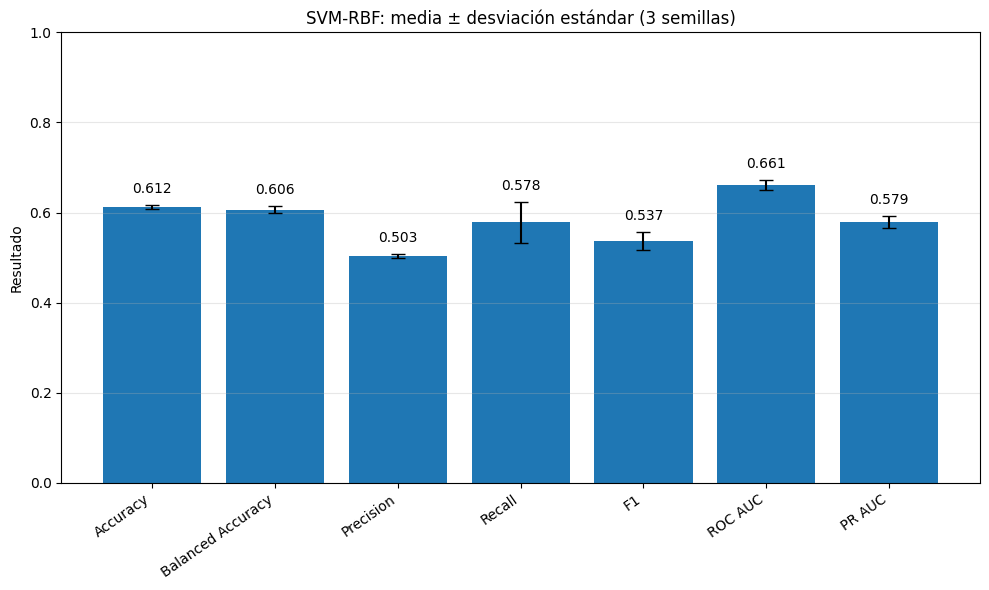

In [19]:
# ============================================================
# 19. FIGURA RESUMEN CON BARRAS DE ERROR
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(summary_metrics_df))

ax.bar(
    x,
    summary_metrics_df["Media"],
    yerr=summary_metrics_df["Desviación estándar"],
    capsize=5
)
ax.set_xticks(x)
ax.set_xticklabels(summary_metrics_df["Métrica"], rotation=35, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Resultado")
ax.set_title("SVM-RBF: media ± desviación estándar (3 semillas)")
ax.grid(axis="y", alpha=0.3)

for i, row in summary_metrics_df.iterrows():
    ax.text(i, row["Media"] + row["Desviación estándar"] + 0.02,
            f"{row['Media']:.3f}", ha="center", va="bottom")

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "resumen_metricas_media_desviacion.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [20]:
# ============================================================
# 20. MANIFIESTO Y VALIDACIONES FINALES DE REPRODUCIBILIDAD
# ============================================================
manifest = {
    "dataset": str(DATA_PATH),
    "target": TARGET,
    "features": EXPECTED_FEATURES,
    "seeds": SEEDS,
    "test_size": TEST_SIZE_MULTI,
    "cv_folds": CV_FOLDS_MULTI,
    "parameter_grid": {
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto", 0.01],
        "kernel": "rbf"
    },
    "primary_metric": "f1",
    "output_directory": str(OUTPUT_DIR)
}

with open(OUTPUT_DIR / "experiment_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

assert set(metrics_by_seed_df["seed"]) == set(SEEDS)
assert len(metrics_by_seed_df) == 3
assert len(all_grid_results_df) == 27  # 3 semillas × 9 combinaciones
assert "Balanced Accuracy" in summary_metrics_df["Métrica"].values

for metric in metric_columns:
    assert metrics_by_seed_df[metric].between(0, 1).all()

required_files = [
    TABLES_DIR / "metricas_por_semilla.csv",
    TABLES_DIR / "tabla_principal_media_desviacion.csv",
    TABLES_DIR / "gridsearch_todas_las_semillas.csv",
    TABLES_DIR / "matrices_confusion_todas_las_semillas.csv",
    TABLES_DIR / "resultados_svm_rbf.xlsx",
    FIGURES_DIR / "resumen_metricas_media_desviacion.png",
    REPORTS_DIR / "mejores_hiperparametros_por_semilla.json",
    OUTPUT_DIR / "experiment_manifest.json"
]
for path in required_files:
    assert path.exists(), f"No se generó el archivo esperado: {path}"

print("✓ Se ejecutaron las semillas 42, 123 y 2026.")
print("✓ Se calculó media ± desviación estándar.")
print("✓ Balanced Accuracy está en la tabla principal.")
print("✓ Figuras guardadas automáticamente a 300 dpi.")
print("✓ Tablas guardadas en CSV y Excel.")
print("✓ Manifiesto del experimento generado.")
print("✓ Validaciones de reproducibilidad completadas.")

✓ Se ejecutaron las semillas 42, 123 y 2026.
✓ Se calculó media ± desviación estándar.
✓ Balanced Accuracy está en la tabla principal.
✓ Figuras guardadas automáticamente a 300 dpi.
✓ Tablas guardadas en CSV y Excel.
✓ Manifiesto del experimento generado.
✓ Validaciones de reproducibilidad completadas.
